In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [9]:
# Load data

df = pd.read_csv("store_data.csv")

# Create a purchase-rate-like feature from the available behavior variables
# Here we use the ratio of spending score to annual income as a proxy for purchase tendency
# Replace any zero income values to avoid division by zero

df["Annual_Income"] = pd.to_numeric(df["Annual_Income"], errors="coerce")
df["Spending_Score"] = pd.to_numeric(df["Spending_Score"], errors="coerce")
df["purchase_rate"] = df["Spending_Score"] / df["Annual_Income"].replace(0, np.nan)

df["purchase_rate"] = df["purchase_rate"].fillna(df["purchase_rate"].median())

# Keep only the features needed for clustering
features = ["Age", "Annual_Income", "Spending_Score", "purchase_rate"]
X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(df[["Age", "Annual_Income", "Spending_Score", "purchase_rate"]].head())
print("\nFeature stats:")
print(X.describe())

   Age  Annual_Income  Spending_Score  purchase_rate
0   56             84              61       0.726190
1   69             86              48       0.558140
2   46             41              19       0.463415
3   32             23               4       0.173913
4   60             76              35       0.460526

Feature stats:
             Age  Annual_Income  Spending_Score  purchase_rate
count  200.00000     200.000000      200.000000     200.000000
mean    43.42500      76.180000       50.140000       0.985026
std     14.94191      36.995146       28.925314       1.041234
min     18.00000      15.000000        1.000000       0.008850
25%     31.00000      44.750000       24.000000       0.315396
50%     43.50000      73.500000       50.500000       0.659897
75%     56.00000     111.000000       69.000000       1.299162
max     69.00000     138.000000       99.000000       5.647059


In [10]:
# Find best number of clusters using silhouette score
best_k, best_score = 2, -1
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_k, best_score = k, score

print("Best number of clusters:", best_k)
print("Silhouette score:", round(best_score, 3))

Best number of clusters: 7
Silhouette score: 0.32


In [11]:
# Apply the 3 algorithms
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df["KMeans"] = kmeans.fit_predict(X_scaled)

df["Hierarchical"] = AgglomerativeClustering(n_clusters=best_k).fit_predict(X_scaled)
df["DBSCAN"] = DBSCAN(eps=1.0, min_samples=5).fit_predict(X_scaled)

# Add cluster centers for interpretation
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("\nCluster centers (original scale):")
print(cluster_centers)



Cluster centers (original scale):
         Age  Annual_Income  Spending_Score  purchase_rate
0  58.945946      97.837838       18.810811       0.201156
1  27.370370      70.629630       78.407407       1.227007
2  53.464286      99.821429       74.464286       0.778490
3  36.206897      40.068966       28.068966       0.793633
4  30.341463     109.097561       37.195122       0.343743
5  41.200000      19.200000       84.800000       4.498994
6  55.785714      38.821429       69.392857       1.876314


In [12]:
# Show results
print(df.head())

# Show cluster summary by purchase rate
cluster_summary = df.groupby("KMeans")["purchase_rate"].agg(["mean", "std", "min", "max", "count"])
print("\nCluster summary by purchase rate:")
print(cluster_summary)

   Age  Annual_Income  Spending_Score  purchase_rate  KMeans  Hierarchical  \
0   56             84              61       0.726190       2             4   
1   69             86              48       0.558140       0             4   
2   46             41              19       0.463415       3             6   
3   32             23               4       0.173913       3             6   
4   60             76              35       0.460526       0             4   

   DBSCAN  
0       0  
1       0  
2       0  
3       0  
4       0  

Cluster summary by purchase rate:
            mean       std       min       max  count
KMeans                                               
0       0.201156  0.148278  0.008850  0.558140     37
1       1.227007  0.402387  0.696970  2.156250     27
2       0.778490  0.228421  0.398551  1.250000     28
3       0.793633  0.517922  0.060606  2.272727     29
4       0.343743  0.154676  0.016129  0.582524     41
5       4.498994  0.772004  3.357143  5.647059

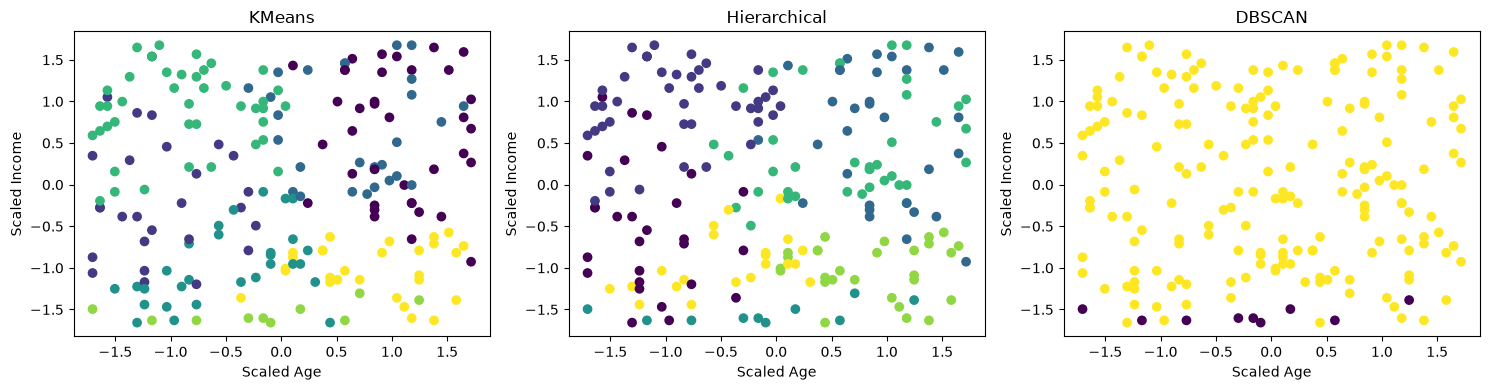

In [13]:
# Quick visualization (first two columns of data)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["KMeans", "Hierarchical", "DBSCAN"]):
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df[col], cmap="viridis")
    ax.set_title(col)
    ax.set_xlabel("Scaled Age")
    ax.set_ylabel("Scaled Income")
plt.tight_layout()
plt.show()